# Penguins species classifier

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [21]:
df = pd.read_csv("data/penguins.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [22]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [23]:
df = df.dropna()

In [24]:
df.species.value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [25]:
species_encoder = LabelEncoder()
island_encoder = LabelEncoder()
sex_encoder = LabelEncoder()

df["species"] = species_encoder.fit_transform(df["species"])
df["island"] = island_encoder.fit_transform(df["island"])
df["sex"] = sex_encoder.fit_transform(df["sex"])

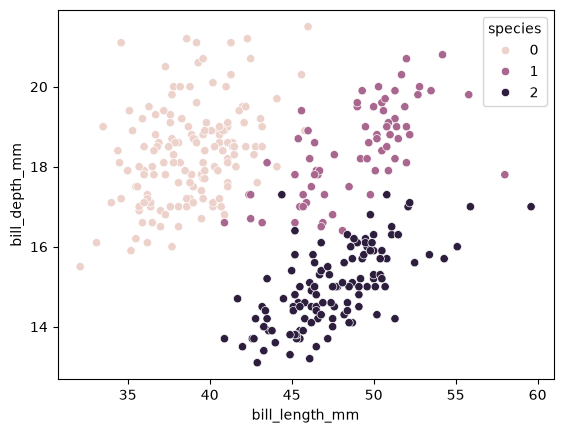

In [26]:
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.show()

In [27]:
df["bill_ratio"] = df["bill_length_mm"] / df["bill_depth_mm"]
df["body_mass_scaled"] = df["body_mass_g"] / 1000
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio,body_mass_scaled
0,0,2,39.1,18.7,181.0,3750.0,1,2.090909,3.75
1,0,2,39.5,17.4,186.0,3800.0,0,2.270115,3.80
2,0,2,40.3,18.0,195.0,3250.0,0,2.238889,3.25
4,0,2,36.7,19.3,193.0,3450.0,0,1.901554,3.45
5,0,2,39.3,20.6,190.0,3650.0,1,1.907767,3.65


In [28]:
X = df[
    [
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
        "bill_ratio",
        "body_mass_scaled",
    ]
]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 266 samples
Test set size: 67 samples


In [29]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Data scaled successfully")

Data scaled successfully


In [30]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [31]:
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)

print("accuracy:", acc)
print(confusion_matrix(y_test, preds))

accuracy: 1.0
[[31  0  0]
 [ 0 13  0]
 [ 0  0 23]]


In [32]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest accuracy: {rf_acc:.4f}")

Random Forest accuracy: 1.0000


In [34]:
lr_model = LogisticRegression(max_iter=100000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
print(f"Logistic Regression accuracy: {lr_acc:.4f}")

Logistic Regression accuracy: 1.0000


In [35]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_preds)
print(f"Gradient Boosting accuracy: {gb_acc:.4f}")

Gradient Boosting accuracy: 1.0000


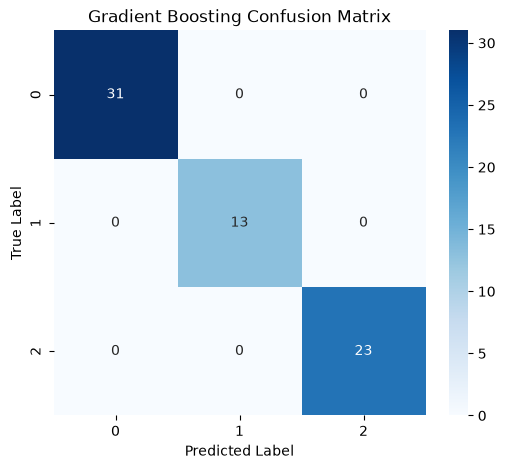

In [36]:
cm = confusion_matrix(y_test, gb_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [37]:
sample = {
    "bill_length_mm": 39.5,
    "bill_depth_mm": 17.4,
    "flipper_length_mm": 187,
    "body_mass_g": 3600,
    "bill_ratio": 2.27,
    "body_mass_scaled": 3.6,
}

In [38]:
sample_df = pd.DataFrame([sample])
sample_df["bill_ratio"] = sample_df["bill_length_mm"] / sample_df["bill_depth_mm"]
sample_df["body_mass_scaled"] = sample_df["body_mass_g"] / 1000
sample_df = sample_df[
    [
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
        "bill_ratio",
        "body_mass_scaled",
    ]
]
sample_scaled = scaler.transform(sample_df)

prediction = gb_model.predict(sample_scaled)[0]
print("Predicted species label:", prediction)
print("Decoded species:", species_encoder.inverse_transform([prediction])[0])

Predicted species label: 0
Decoded species: Adelie
